<a href="https://colab.research.google.com/github/Dassie-Franck/server/blob/main/train_model_traffic_signs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Verifications des ressource avant le traitement du dataset

In [1]:
# ── CELLULE 5 : Tout en une seule cellule (le plus pratique) ────
import torch
import psutil
import os

# GPU
print("=" * 40)
print("           GPU")
print("=" * 40)
if torch.cuda.is_available():
    print(f"Nom         : {torch.cuda.get_device_name(0)}")
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    libre_vram = torch.cuda.memory_reserved(0) / 1024**3
    print(f"VRAM totale : {total_vram:.1f} GB")
    print(f"CUDA        : {torch.version.cuda}")
else:
    print(" Pas de GPU — change le runtime !")

# CPU
print("\n" + "=" * 40)
print("           CPU")
print("=" * 40)
cpu_info = os.popen("cat /proc/cpuinfo | grep 'model name' | head -1").read()
print(f"Modèle  : {cpu_info.split(':')[1].strip()}")
print(f"Coeurs  : {psutil.cpu_count()} coeurs logiques")

# RAM
print("\n" + "=" * 40)
print("           RAM")
print("=" * 40)
ram = psutil.virtual_memory()
print(f"Totale    : {ram.total  / 1024**3:.1f} GB")
print(f"Utilisée  : {ram.used   / 1024**3:.1f} GB")
print(f"Libre     : {ram.available / 1024**3:.1f} GB")

# Stockage
print("\n" + "=" * 40)
print("           STOCKAGE")
print("=" * 40)
disk = psutil.disk_usage('/content')
print(f"Total   : {disk.total / 1024**3:.1f} GB")
print(f"Utilisé : {disk.used  / 1024**3:.1f} GB")
print(f"Libre   : {disk.free  / 1024**3:.1f} GB")

           GPU
Nom         : Tesla T4
VRAM totale : 14.6 GB
CUDA        : 12.8

           CPU
Modèle  : Intel(R) Xeon(R) CPU @ 2.00GHz
Coeurs  : 2 coeurs logiques

           RAM
Totale    : 12.7 GB
Utilisée  : 1.2 GB
Libre     : 11.2 GB

           STOCKAGE
Total   : 112.6 GB
Utilisé : 43.5 GB
Libre   : 69.1 GB


In [1]:
!pip install ultralytics roboflow -q
print("Installation terminée !")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 138.3 MB/s eta 0:00:00
Installation terminée !


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs("/content/drive/MyDrive/CARLA_panneaux", exist_ok=True)
print(" Google Drive monté — modèle sauvegardé automatiquement !")

Mounted at /content/drive
 Google Drive monté — modèle sauvegardé automatiquement !


In [7]:
# ── CELLULE 1 : Désinstaller l'ancienne version et installer la dernière ──
!pip install --upgrade ultralytics -q

Verification des dependence et des differentes version installer

In [8]:
# ── CELLULE 2 : Voir la version installée ────────────────────────
import ultralytics
print(f"Version Ultralytics : {ultralytics.__version__}")

# Voir tous les modèles YOLO disponibles
from ultralytics import YOLO
print("\nModèles disponibles :")
!yolo checks

Version Ultralytics : 8.4.21

Modèles disponibles :
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.7/112.6 GB disk)

OS                     Linux-6.6.113+-x86_64-with-glibc2.35
Environment            Colab
Python                 3.12.12
Install                pip
Path                   /usr/local/lib/python3.12/dist-packages/ultralytics
RAM                    12.67 GB
Disk                   43.7/112.6 GB
CPU                    Intel Xeon CPU @ 2.00GHz
CPU count              2
GPU                    Tesla T4, 14913MiB
GPU count              1
CUDA                   12.8

numpy                  ✅ 2.0.2>=1.23.0
matplotlib             ✅ 3.10.0>=3.3.0
opencv-python          ✅ 4.13.0.92>=4.6.0
pillow                 ✅ 11.3.0>=7.1.2
pyyaml                 ✅ 6.0.3>=5.3.1
requests               ✅ 2.32.4>=2.23.0
scipy                  ✅ 1.16.3>=1.4.1
torch                  ✅ 2.10.0+cu128>=1.8.0
torch                  ✅

installation du model YOLOV26

In [9]:
# ── CELLULE 3 : Voir la version + tester un modèle ───────────────
from ultralytics import YOLO
import torch

print("=" * 40)
print("     ULTRALYTICS / YOLO")
print("=" * 40)

import ultralytics
print(f"Version Ultralytics : {ultralytics.__version__}")
print(f"PyTorch             : {torch.__version__}")
print(f"CUDA disponible     : {torch.cuda.is_available()}")

print("\n" + "=" * 40)
print("     MODÈLES DISPONIBLES")
print("=" * 40)
print("YOLO11 : yolo11n / yolo11s / yolo11m / yolo11l / yolo11x")
print("YOLO26 : yolo26n / yolo26s / yolo26m / yolo26l / yolo26x")

print("\n" + "=" * 40)
print("     TEST CHARGEMENT MODÈLE")
print("=" * 40)

# Tester quel modèle est disponible
modeles = ["yolo26s.pt", "yolo11s.pt", "yolov8s.pt"]

for modele in modeles:
    try:
        model = YOLO(modele)
        print(f" {modele} → chargé avec succès !")
        break
    except Exception as e:
        print(f" {modele} → non disponible")

     ULTRALYTICS / YOLO
Version Ultralytics : 8.4.21
PyTorch             : 2.10.0+cu128
CUDA disponible     : True

     MODÈLES DISPONIBLES
YOLO11 : yolo11n / yolo11s / yolo11m / yolo11l / yolo11x
YOLO26 : yolo26n / yolo26s / yolo26m / yolo26l / yolo26x

     TEST CHARGEMENT MODÈLE
✅ yolo26s.pt → chargé avec succès !


Configuration de Kaggle et telechargement du dataset dans mon Drive

In [1]:
!pip install kagglehub -q

# Configurer Kaggle
from google.colab import files
print("Uploade ton fichier kaggle.json")
files.upload()

import os
os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)
print(" Kaggle configuré !")

Uploade ton fichier kaggle.json


Saving kaggle.json to kaggle.json
 Kaggle configuré !


Montage du Drive pour la communication avec mon colab

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs("/content/drive/MyDrive/projet_ADAS/datasets/panneaux", exist_ok=True)
print(" Google Drive monté !")

Mounted at /content/drive
✅ Google Drive monté !


Telechargement du dataset sur kaggle

In [3]:
import kagglehub

print(" Téléchargement en cours...")
path = kagglehub.dataset_download("valentynsichkar/traffic-signs-preprocessed")
print(f" Dataset téléchargé !")
print(f"Chemin : {path}")

⏳ Téléchargement en cours...


100%|██████████| 4.16G/4.16G [00:44<00:00, 100MB/s]

Extracting files...


✅ Dataset téléchargé !
📁 Chemin : /root/.cache/kagglehub/datasets/valentynsichkar/traffic-signs-preprocessed/versions/2


Verification de la structure du dataset apres telechargement

In [4]:
import os

print("=== Structure du dataset ===\n")
for root, dirs, files in os.walk(path):
    niveau = root.replace(path, "").count(os.sep)
    indent = "  " * niveau
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:3]:
        print(f"{indent}  → {f}")
    if len(files) > 3:
        print(f"{indent}  ... ({len(files)} fichiers au total)")

=== Structure du dataset ===

2/
  → data7.pickle
  → data8.pickle
  → data0.pickle
  ... (19 fichiers au total)


Copie du dataset vers mon Drive Projet_ADAS

In [5]:
import shutil

destination = "/content/drive/MyDrive/projet_ADAS/datasets/panneaux"

print("⏳ Copie vers Google Drive...")
shutil.copytree(path, destination, dirs_exist_ok=True)

# Vérifier taille
total_fichiers = sum(len(f) for _, _, f in os.walk(destination))
taille = sum(
    os.path.getsize(os.path.join(r, f))
    for r, _, files in os.walk(destination)
    for f in files
) / 1024**3

print(f" Dataset copié dans Google Drive !")
print(f"{destination}")
print(f"  Fichiers : {total_fichiers}")
print(f" Taille   : {taille:.2f} GB")

⏳ Copie vers Google Drive...
✅ Dataset copié dans Google Drive !
📁 /content/drive/MyDrive/projet_ADAS/datasets/panneaux
🖼️  Fichiers : 19
💾 Taille   : 6.55 GB


In [9]:
import os

# Afficher le chemin exact retourné par kagglehub
print(f"Chemin dataset : {path}")
print(f"\nContenu du chemin :")

for root, dirs, files in os.walk(path):
    print(f"\n {root}")
    for f in files:
        taille = os.path.getsize(os.path.join(root, f)) / 1024**2
        print(f"   → {f}  ({taille:.1f} MB)")

Chemin dataset : /root/.cache/kagglehub/datasets/valentynsichkar/traffic-signs-preprocessed/versions/2

Contenu du chemin :

📁 /root/.cache/kagglehub/datasets/valentynsichkar/traffic-signs-preprocessed/versions/2
   → data7.pickle  (407.0 MB)
   → data8.pickle  (407.0 MB)
   → data0.pickle  (455.2 MB)
   → data6.pickle  (407.0 MB)
   → labels.pickle  (0.0 MB)
   → data4.pickle  (813.4 MB)
   → valid.pickle  (12.9 MB)
   → data2.pickle  (1219.8 MB)
   → train.pickle  (102.2 MB)
   → std_rgb.pickle  (0.0 MB)
   → mean_image_gray.pickle  (0.0 MB)
   → datasets_preparing.py  (0.0 MB)
   → data1.pickle  (1219.8 MB)
   → test.pickle  (37.1 MB)
   → std_gray.pickle  (0.0 MB)
   → mean_image_rgb.pickle  (0.0 MB)
   → data3.pickle  (1219.8 MB)
   → data5.pickle  (407.0 MB)
   → label_names.csv  (0.0 MB)


In [10]:
import pickle
import numpy as np

pickle_path = "/root/.cache/kagglehub/datasets/valentynsichkar/traffic-signs-preprocessed/versions/2"

# Ouvrir train.pickle
with open(f"{pickle_path}/train.pickle", 'rb') as f:
    train = pickle.load(f, encoding='latin1')

print(f"Type          : {type(train)}")
print(f"Clés          : {list(train.keys()) if isinstance(train, dict) else 'pas un dict'}")

if isinstance(train, dict):
    for key, val in train.items():
        if hasattr(val, 'shape'):
            print(f"  {key} → shape : {val.shape} | dtype : {val.dtype}")
        else:
            print(f"  {key} → {type(val)}")

Type          : <class 'dict'>
Clés          : ['coords', 'labels', 'features', 'sizes']
  coords → shape : (34799, 4) | dtype : uint8
  labels → shape : (34799,) | dtype : uint8
  features → shape : (34799, 32, 32, 3) | dtype : uint8
  sizes → shape : (34799, 2) | dtype : uint8


Images shape    : (34799, 32, 32, 3)
Labels shape    : (34799,)
Classes uniques : 43
Valeurs min/max : 0 / 255


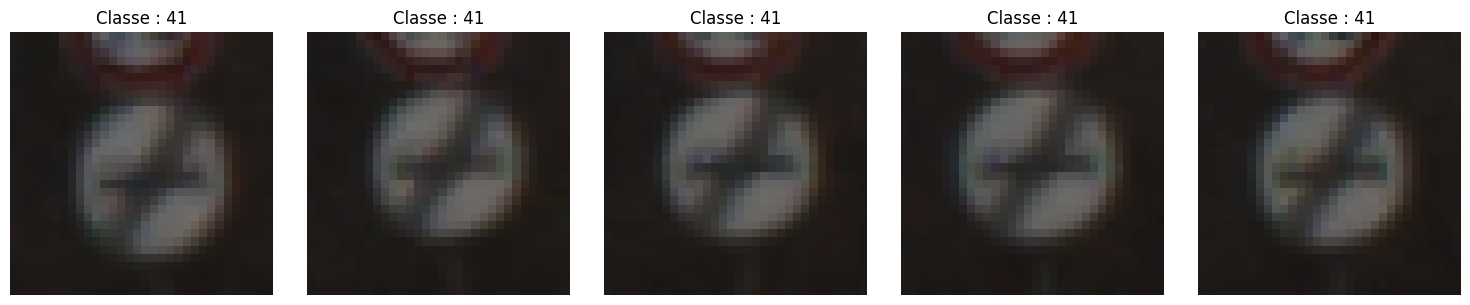

In [11]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open(f"{pickle_path}/train.pickle", 'rb') as f:
    train = pickle.load(f, encoding='latin1')

# Récupérer images et labels
images = train.get('features', train.get('x', train.get('X', None)))
labels = train.get('labels',   train.get('y', train.get('Y', None)))

print(f"Images shape    : {images.shape}")
print(f"Labels shape    : {labels.shape}")
print(f"Classes uniques : {len(np.unique(labels))}")
print(f"Valeurs min/max : {images.min()} / {images.max()}")

# Afficher 5 exemples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(f"Classe : {labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

labels_path = f"{pickle_path}/label_names.csv"
df_classes  = pd.read_csv(labels_path)
print(df_classes)

    ClassId                                           SignName
0         0                               Speed limit (20km/h)
1         1                               Speed limit (30km/h)
2         2                               Speed limit (50km/h)
3         3                               Speed limit (60km/h)
4         4                               Speed limit (70km/h)
5         5                               Speed limit (80km/h)
6         6                        End of speed limit (80km/h)
7         7                              Speed limit (100km/h)
8         8                              Speed limit (120km/h)
9         9                                         No passing
10       10       No passing for vehicles over 3.5 metric tons
11       11              Right-of-way at the next intersection
12       12                                      Priority road
13       13                                              Yield
14       14                                            

In [13]:
import pickle
import numpy as np
import os
from PIL import Image

pickle_path = "/root/.cache/kagglehub/datasets/valentynsichkar/traffic-signs-preprocessed/versions/2"
output_path = "/content/drive/MyDrive/projet_ADAS/datasets/panneaux"

def convertir_en_yolo(pickle_file, split):
    print(f"\n Conversion {split}...")

    with open(f"{pickle_path}/{pickle_file}", 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    images = data['features']   # (N, 32, 32, 3)
    labels = data['labels']     # (N,)
    coords = data['coords']     # (N, 4) → x1, y1, x2, y2
    sizes  = data['sizes']      # (N, 2) → hauteur, largeur originales

    img_dir = os.path.join(output_path, split, "images")
    lbl_dir = os.path.join(output_path, split, "labels")
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    for i in range(len(images)):
        # ── Sauvegarder l'image ───────────────────────────────────
        img      = Image.fromarray(images[i])
        img_name = f"{split}_{i:05d}.jpg"
        img.save(os.path.join(img_dir, img_name))

        # ── Convertir coords en format YOLO ──────────────────────
        # coords = [x1, y1, x2, y2] en pixels originaux
        h_orig, w_orig = sizes[i][0], sizes[i][1]
        x1, y1, x2, y2 = coords[i]

        # Format YOLO : x_centre, y_centre, largeur, hauteur (0 à 1)
        x_centre = ((x1 + x2) / 2) / w_orig
        y_centre = ((y1 + y2) / 2) / h_orig
        largeur  = (x2 - x1) / w_orig
        hauteur  = (y2 - y1) / h_orig

        # Clamp entre 0 et 1
        x_centre = max(0, min(1, x_centre))
        y_centre = max(0, min(1, y_centre))
        largeur  = max(0, min(1, largeur))
        hauteur  = max(0, min(1, hauteur))

        # ── Sauvegarder le label YOLO ─────────────────────────────
        lbl_name = f"{split}_{i:05d}.txt"
        with open(os.path.join(lbl_dir, lbl_name), 'w') as f:
            f.write(f"{labels[i]} {x_centre:.6f} {y_centre:.6f} {largeur:.6f} {hauteur:.6f}\n")

    print(f" {split} : {len(images)} images converties")
    return len(images)

# Convertir les 3 splits
n_train = convertir_en_yolo("train.pickle", "train")
n_valid = convertir_en_yolo("valid.pickle", "valid")
n_test  = convertir_en_yolo("test.pickle",  "test")

print(f"\n{'='*45}")
print(f" Conversion terminée !")
print(f"   Train : {n_train} images")
print(f"   Valid : {n_valid} images")
print(f"   Test  : {n_test}  images")


⏳ Conversion train...
✅ train : 34799 images converties

⏳ Conversion valid...
✅ valid : 4410 images converties

⏳ Conversion test...


/tmp/ipykernel_6447/2827256243.py:37: RuntimeWarning: overflow encountered in scalar add
  x_centre = ((x1 + x2) / 2) / w_orig


✅ test : 12630 images converties

✅ Conversion terminée !
   Train : 34799 images
   Valid : 4410 images
   Test  : 12630  images


Mise a jour du code , creation du data.yaml

In [6]:
import pandas as pd
import yaml

# Lire les noms des classes
df      = pd.read_csv(f"{pickle_path}/label_names.csv")
noms    = df.iloc[:, 0].tolist()   # première colonne = noms

config = {
    "path"  : "/content/drive/MyDrive/projet_ADAS/datasets/panneaux",
    "train" : "train/images",
    "val"   : "valid/images",
    "test"  : "test/images",
    "nc"    : 43,
    "names" : {i: noms[i] for i in range(len(noms))}
}

yaml_path = f"{output_path}/data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(config, f, allow_unicode=True, sort_keys=False)

print(" data.yaml créé !")
print(f"\nContenu :")
with open(yaml_path, 'r') as f:
    print(f.read())

 Drive non monté — remonte le drive d'abord !
Mounted at /content/drive
 label_names.csv introuvable dans : /root/.cache/kagglehub/datasets/valentynsichkar/traffic-signs-preprocessed/versions/2


Code de verification pas a prendre a compte , juste le chache colab perdu , nous allons connecter sur le drive une fnouvelle fois pour creer le data.yaml    etape1:

In [7]:
import pandas as pd
import yaml
import os
from google.colab import drive

# Monter Drive
drive.mount('/content/drive')

drive_path = "/content/drive/MyDrive/projet_ADAS/datasets/panneaux"

# Lister ce qui est dans le dossier
print("Contenu du dossier panneaux :")
for f in os.listdir(drive_path):
    print(f"   → {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contenu du dossier panneaux :
   → data0.pickle
   → data1.pickle
   → data2.pickle
   → data3.pickle
   → data4.pickle
   → data5.pickle
   → data6.pickle
   → data7.pickle
   → mean_image_rgb.pickle
   → data8.pickle
   → test.pickle
   → label_names.csv
   → std_gray.pickle
   → std_rgb.pickle
   → datasets_preparing.py
   → labels.pickle
   → mean_image_gray.pickle
   → train.pickle
   → valid.pickle
   → train


Monter le Drive a chaque fois qu'il se deconnecte

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

# Trouver le bon chemin
base = "/content/drive/MyDrive"
print("Contenu de MyDrive :")
for f in os.listdir(base):
    print(f"   → {f}")

Mounted at /content/drive
Contenu de MyDrive :
   → WhatsApp-Image-2023-11-05-at-1.07.32-AM.jpg
   → Colab Notebooks
   → stockage.jpg
   → pfSense-CE-2.7.2-RELEASE-amd64.rar
   → stockage.drawio
   → cvx
   → projetTutoree
   → CARLA_panneaux
   → projet_ADAS


Etape2:

In [6]:
import pickle
import numpy as np
import os
from PIL import Image

drive_path  = "/content/drive/MyDrive/projet_ADAS/datasets/panneaux"

def convertir_pickle(pickle_file, split):
    print(f"\n⏳ Conversion {split}...")

    with open(f"{drive_path}/{pickle_file}", 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    images = data['features']
    labels = data['labels']
    coords = data['coords']
    sizes  = data['sizes']

    img_dir = f"{drive_path}/{split}/images"
    lbl_dir = f"{drive_path}/{split}/labels"
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    for i in range(len(images)):
        # Sauvegarder image
        img = Image.fromarray(images[i])
        img.save(f"{img_dir}/{split}_{i:05d}.jpg")

        # Convertir coords en format YOLO
        h_orig, w_orig = sizes[i][0], sizes[i][1]
        x1, y1, x2, y2 = coords[i]

        x_centre = max(0, min(1, ((x1 + x2) / 2) / w_orig))
        y_centre = max(0, min(1, ((y1 + y2) / 2) / h_orig))
        largeur  = max(0, min(1, (x2 - x1) / w_orig))
        hauteur  = max(0, min(1, (y2 - y1) / h_orig))

        # Sauvegarder label YOLO
        with open(f"{lbl_dir}/{split}_{i:05d}.txt", 'w') as f:
            f.write(f"{labels[i]} {x_centre:.6f} {y_centre:.6f} {largeur:.6f} {hauteur:.6f}\n")

    print(f"✅ {split} : {len(images)} images + {len(images)} labels créés")
    return len(images)

# Créer valid et test
n_valid = convertir_pickle("valid.pickle", "valid")
n_test  = convertir_pickle("test.pickle",  "test")

print(f"\n{'='*45}")
print(f"✅ valid : {n_valid} images")
print(f"✅ test  : {n_test}  images")


⏳ Conversion valid...
✅ valid : 4410 images + 4410 labels créés

⏳ Conversion test...


/tmp/ipykernel_1020/4248881708.py:33: RuntimeWarning: overflow encountered in scalar add
  x_centre = max(0, min(1, ((x1 + x2) / 2) / w_orig))


✅ test : 12630 images + 12630 labels créés

✅ valid : 4410 images
✅ test  : 12630  images


Corriger le train

In [8]:
import os

drive_path = "/content/drive/MyDrive/projet_ADAS/datasets/panneaux"
img_dir    = f"{drive_path}/train/images"
lbl_dir    = f"{drive_path}/train/labels"

images = set(f.replace(".jpg", "") for f in os.listdir(img_dir))
labels = set(f.replace(".txt", "") for f in os.listdir(lbl_dir))

sans_label = images - labels
print(f"Images sans label : {sans_label}")

for nom in sans_label:
    os.remove(f"{img_dir}/{nom}.jpg")
    print(f" Supprimé : {nom}.jpg")

n_img = len(os.listdir(img_dir))
n_lbl = len(os.listdir(lbl_dir))
print(f"\n Train corrigé : {n_img} images | {n_lbl} labels")

Images sans label : {'train_32915'}
 Supprimé : train_32915.jpg

 Train corrigé : 32915 images | 32915 labels


creation du data.yaml

In [9]:
import pandas as pd
import yaml

drive_path = "/content/drive/MyDrive/projet_ADAS/datasets/panneaux"

df   = pd.read_csv(f"{drive_path}/label_names.csv")
noms = df['SignName'].tolist()

config = {
    "path"  : drive_path,
    "train" : "train/images",
    "val"   : "valid/images",
    "test"  : "test/images",
    "nc"    : len(noms),
    "names" : {i: noms[i] for i in range(len(noms))}
}

yaml_path = f"{drive_path}/data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(config, f, allow_unicode=True, sort_keys=False)

print(" data.yaml créé !")

 data.yaml créé !


Verification final avant entrainement du model

In [10]:
import os

drive_path = "/content/drive/MyDrive/projet_ADAS/datasets/panneaux"

print("=== Vérification finale ===\n")
for split in ["train", "valid", "test"]:
    img = len(os.listdir(f"{drive_path}/{split}/images"))
    lbl = len(os.listdir(f"{drive_path}/{split}/labels"))
    ok  = "ok " if img == lbl else "echec"
    print(f"{ok} {split:6s} → {img} images | {lbl} labels")

yaml_ok = "ok" if os.path.exists(f"{drive_path}/data.yaml") else "echec"
print(f"\n{yaml_ok} data.yaml présent")
print(f"\n  Dataset 100% prêt — on peut lancer l'entraînement !")

=== Vérification finale ===

ok  train  → 32915 images | 32915 labels
ok  valid  → 4410 images | 4410 labels
ok  test   → 12630 images | 12630 labels

ok data.yaml présent

  Dataset 100% prêt — on peut lancer l'entraînement !


In [12]:
import os

yaml_path = "/content/drive/MyDrive/projet_ADAS/datasets/panneaux/data.yaml"

if os.path.exists(yaml_path):
    taille = os.path.getsize(yaml_path)
    print(f" data.yaml existe bien !")
    print(f"📦 Taille : {taille} octets")
    print(f"\nContenu :")
    with open(yaml_path, 'r') as f:
        print(f.read())
else:
    print("❌ data.yaml introuvable")


 data.yaml existe bien !
📦 Taille : 1240 octets

Contenu :
path: /content/drive/MyDrive/projet_ADAS/datasets/panneaux
train: train/images
val: valid/images
test: test/images
nc: 43
names:
  0: Speed limit (20km/h)
  1: Speed limit (30km/h)
  2: Speed limit (50km/h)
  3: Speed limit (60km/h)
  4: Speed limit (70km/h)
  5: Speed limit (80km/h)
  6: End of speed limit (80km/h)
  7: Speed limit (100km/h)
  8: Speed limit (120km/h)
  9: No passing
  10: No passing for vehicles over 3.5 metric tons
  11: Right-of-way at the next intersection
  12: Priority road
  13: Yield
  14: Stop
  15: No vehicles
  16: Vehicles over 3.5 metric tons prohibited
  17: No entry
  18: General caution
  19: Dangerous curve to the left
  20: Dangerous curve to the right
  21: Double curve
  22: Bumpy road
  23: Slippery road
  24: Road narrows on the right
  25: Road work
  26: Traffic signals
  27: Pedestrians
  28: Children crossing
  29: Bicycles crossing
  30: Beware of ice/snow
  31: Wild animals crossing

In [15]:
import os

output_path = "/content/drive/MyDrive/projet_ADAS/datasets/panneaux"

for split in ["train", "valid", "test"]:
    n_images = len(os.listdir(f"{output_path}/{split}/images"))
    n_labels = len(os.listdir(f"{output_path}/{split}/labels"))
    statut   = "ok" if n_images == n_labels else ""
    print(f"{statut} {split:6s} → {n_images} images | {n_labels} labels")

print(f"\n Dataset prêt dans Google Drive !")
print(f" Config : {output_path}/data.yaml")
print(f"\n  Prochaine étape : entraîner YOLO26 !")

ok train  → 34799 images | 34799 labels
ok valid  → 4410 images | 4410 labels
ok test   → 12630 images | 12630 labels

 Dataset prêt dans Google Drive !
 Config : /content/drive/MyDrive/projet_ADAS/datasets/panneaux/data.yaml

  Prochaine étape : entraîner YOLO26 !


In [1]:
import torch
print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

GPU  : Tesla T4
VRAM : 14.6 GB


Entrainement du model

> Ajouter une citation Etape1 : Installation des dependance



In [3]:
# Installer ultralytics
!pip install ultralytics -q

# Verifier l installation
import ultralytics
import torch

print(f"Ultralytics : {ultralytics.__version__}")
print(f"PyTorch     : {torch.__version__}")
print(f"GPU         : {torch.cuda.get_device_name(0)}")
print("Installation terminee - relance la cellule d entrainement !")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics : 8.4.22
PyTorch     : 2.10.0+cu128
GPU         : Tesla T4
Installation terminee - relance la cellule d entrainement !


Etape2 : Entrainement du model

In [1]:
# Copier le dataset en local dans Colab d abord
# Ensuite l entrainement sera beaucoup plus rapide

import shutil
import os

drive_path = "/content/drive/MyDrive/projet_ADAS/datasets/panneaux"
local_path = "/content/dataset_panneaux"

print("Copie du dataset Drive vers Colab local...")
print("Cela prend environ 10-15 minutes mais l entrainement sera 3x plus rapide\n")

for split in ["train", "valid", "test"]:
    src  = f"{drive_path}/{split}"
    dest = f"{local_path}/{split}"
    print(f"Copie {split}...")
    shutil.copytree(src, dest, dirs_exist_ok=True)
    n = len(os.listdir(f"{dest}/images"))
    print(f"  {split} : {n} images copiees")

# Copier data.yaml
shutil.copy(f"{drive_path}/data.yaml", f"{local_path}/data.yaml")
shutil.copy(f"{drive_path}/label_names.csv", f"{local_path}/label_names.csv")

print("\nDataset copie en local !")
print(f"Chemin local : {local_path}")

Copie du dataset Drive vers Colab local...
Cela prend environ 10-15 minutes mais l entrainement sera 3x plus rapide

Copie train...


KeyboardInterrupt: 

In [ ]:
# ================================================================
# ENTRAINEMENT YOLO26 - PANNEAUX DE SIGNALISATION
# SYSTEME DE REPRISE AUTOMATIQUE - RELANCER A CHAQUE SESSION
#
# Problemes resolus :
#   1. Images 32x32 trop petites  -> imgsz=128
#   2. Fragile aux intemperies    -> augmentation hsv + mosaic
#   3. Detection a grande vitesse -> scale + perspective + shear
#
# Instructions :
#   Session 1 -> lance cette cellule -> attend -> Colab coupe
#   Session 2 -> relance cette cellule -> reprend automatiquement
#   Session 3 -> relance cette cellule -> termine a epoch 100
# ================================================================

# ----------------------------------------------------------------
# ETAPE 1 : INSTALLATION ET MONTAGE
# ----------------------------------------------------------------

import subprocess
subprocess.run(["pip", "install", "ultralytics", "-q"],
               capture_output=True)

from ultralytics import YOLO
from google.colab import drive
import torch
import os
import yaml
import pandas as pd

# Monter Google Drive
drive.mount('/content/drive', force_remount=True)
print("Drive monte !")

# ----------------------------------------------------------------
# ETAPE 2 : DEFINITION DES CHEMINS
# ----------------------------------------------------------------

DRIVE_BASE  = "/content/drive/MyDrive/projet_ADAS"
DATASET     = f"{DRIVE_BASE}/datasets/panneaux"
MODELS_DIR  = f"{DRIVE_BASE}/models/panneaux"
MODEL_NAME  = "yolo26s_panneaux_robuste"
YAML_PATH   = f"{DATASET}/data.yaml"
LAST_PT     = f"{MODELS_DIR}/{MODEL_NAME}/weights/last.pt"
BEST_PT     = f"{MODELS_DIR}/{MODEL_NAME}/weights/best.pt"

# Creer le dossier modeles si inexistant
os.makedirs(MODELS_DIR, exist_ok=True)

# ----------------------------------------------------------------
# ETAPE 3 : VERIFICATION SYSTEME
# ----------------------------------------------------------------

print("\n=== Verification systeme ===")
print(f"GPU      : {torch.cuda.get_device_name(0)}")
print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"PyTorch  : {torch.__version__}")

print("\n=== Verification dataset ===")
total_images = 0
for split in ["train", "valid", "test"]:
    chemin = f"{DATASET}/{split}/images"
    if os.path.exists(chemin):
        n = len(os.listdir(chemin))
        total_images += n
        print(f"  {split:6s} : {n} images")
    else:
        print(f"  {split:6s} : MANQUANT")

print(f"  Total  : {total_images} images")
print(f"\n  data.yaml : {'OK' if os.path.exists(YAML_PATH) else 'MANQUANT'}")

# ----------------------------------------------------------------
# ETAPE 4 : DETECTION DU CHECKPOINT
# Determine si on demarre ou on reprend
# ----------------------------------------------------------------

print("\n=== Detection checkpoint ===")

if os.path.exists(LAST_PT):
    taille_last = os.path.getsize(LAST_PT) / 1024**2
    print(f"  last.pt trouve : {taille_last:.1f} MB")

    if os.path.exists(BEST_PT):
        taille_best = os.path.getsize(BEST_PT) / 1024**2
        print(f"  best.pt trouve : {taille_best:.1f} MB")

    # Lire le nombre d epochs deja faites
    results_csv = f"{MODELS_DIR}/{MODEL_NAME}/results.csv"
    if os.path.exists(results_csv):
        df_res        = pd.read_csv(results_csv)
        epochs_faites = len(df_res)
        print(f"  Epochs deja faites : {epochs_faites}/100")
        print(f"  Epochs restantes   : {100 - epochs_faites}/100")

    print("\n  REPRISE de l entrainement depuis le checkpoint")
    model  = YOLO(LAST_PT)
    resume = True

else:
    print("  Aucun checkpoint trouve")
    print("\n  DEBUT de l entrainement depuis zero")
    model  = YOLO("yolo26s.pt")
    resume = False

# ----------------------------------------------------------------
# ETAPE 5 : LANCEMENT DE L ENTRAINEMENT
# ----------------------------------------------------------------

print("\n=== Lancement entrainement ===\n")

results = model.train(

    # Donnees
    data         = YAML_PATH,

    # Reprise automatique
    resume       = resume,
    exist_ok     = True,

    # Taille images
    # Probleme 1 resolu : images 32x32 redimensionnees a 128x128
    # YOLO26 gere automatiquement le redimensionnement
    imgsz        = 128,

    # Parametres entrainement
    epochs       = 100,
    batch        = 32,
    device       = "cuda",
    patience     = 15,

    # Sauvegarde dans Drive
    project      = MODELS_DIR,
    name         = MODEL_NAME,

    # Sauvegarde a chaque epoch
    # Garantit que last.pt est toujours disponible
    # meme si Colab coupe a nimporte quelle epoch
    save_period  = 1,

    # Probleme 2 resolu : Robustesse aux intemperies
    # hsv_h = variation teinte  (differentes couleurs de lumiere)
    # hsv_s = variation saturation (pluie brouillard temps couvert)
    # hsv_v = variation luminosite (nuit soleil ombre contre-jour)
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,

    # Probleme 3 resolu : Robustesse a la grande vitesse
    # scale       = zoom 50%    (panneau loin ou pres a grande vitesse)
    # translate   = deplacement (panneau pas centre en mouvement)
    # degrees     = rotation    (vibrations de la voiture)
    # shear       = cisaillement (angle de vue en virage)
    # perspective = deformation (hauteur variable camera embarquee)
    scale        = 0.5,
    translate    = 0.1,
    degrees      = 10.0,
    shear        = 2.0,
    perspective  = 0.0001,

    # Robustesse generale
    # fliplr     = miroir horizontal (panneaux des deux cotes)
    # mosaic     = melange 4 images (plusieurs panneaux simultanes)
    # mixup      = melange 2 images (ameliore la generalisation)
    # copy_paste = copie objets entre images (diversite positions)
    fliplr       = 0.5,
    mosaic       = 1.0,
    mixup        = 0.1,
    copy_paste   = 0.1,

    # Optimiseur AdamW
    # lr0          = taux apprentissage initial
    # lrf          = taux apprentissage final
    # weight_decay = evite le surapprentissage
    # warmup       = demarrage progressif sur 3 epochs
    optimizer     = "AdamW",
    lr0           = 0.001,
    lrf           = 0.01,
    weight_decay  = 0.0005,
    warmup_epochs = 3,

    # Performance
    cache        = False,     # pas de cache (economise espace disque)
    workers      = 2,
    verbose      = True
)

# ----------------------------------------------------------------
# ETAPE 6 : BILAN DE LA SESSION
# ----------------------------------------------------------------

print("\n" + "=" * 55)

if os.path.exists(BEST_PT):
    taille = os.path.getsize(BEST_PT) / 1024**2

    # Lire les resultats
    results_csv = f"{MODELS_DIR}/{MODEL_NAME}/results.csv"
    if os.path.exists(results_csv):
        df_res        = pd.read_csv(results_csv)
        df_res.columns = df_res.columns.str.strip()
        epochs_faites  = len(df_res)
        derniere_map   = df_res['metrics/mAP50(B)'].iloc[-1]
        meilleure_map  = df_res['metrics/mAP50(B)'].max()

        print(f"SESSION TERMINEE")
        print(f"  Epochs faites    : {epochs_faites}/100")
        print(f"  mAP50 actuel     : {derniere_map:.3f}")
        print(f"  Meilleur mAP50   : {meilleure_map:.3f}")
        print(f"  Taille best.pt   : {taille:.1f} MB")

        if epochs_faites >= 100:
            print("\n  ENTRAINEMENT COMPLET - 100 epochs terminees !")
            print("  Prochaine etape : visualiser les resultats")
        else:
            restantes = 100 - epochs_faites
            print(f"\n  {restantes} epochs restantes")
            print("  Relance cette cellule pour continuer")
else:
    print("ENTRAINEMENT INTERROMPU AVANT LA FIN")
    print("Relance cette cellule pour reprendre")

print("=" * 55)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Drive monte !

=== Verification systeme ===
GPU      : Tesla T4
VRAM     : 14.6 GB
PyTorch  : 2.10.0+cu128

=== Verification dataset ===
  train  : 32915 images
  valid  : 4410 images
  test   : 12630 images
  Total  : 49955 images

  data.yaml : OK

=== Detection checkpoint ===
  Aucun checkpoint trouve

  DEBUT de l entrainement depuis zero

=== Lancement entrainement ===

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

last_pt = "/content/drive/MyDrive/projet_ADAS/models/panneaux/yolo26s_panneaux_robuste/weights/last.pt"
best_pt = "/content/drive/MyDrive/projet_ADAS/models/panneaux/yolo26s_panneaux_robuste/weights/best.pt"

if os.path.exists(last_pt):
    taille = os.path.getsize(last_pt) / 1024**2
    print(f"last.pt trouve : {taille:.1f} MB")
    print("On peut reprendre depuis epoch 8 !")
else:
    print("last.pt introuvable")
    print("Il faut recommencer depuis le debut")

Mounted at /content/drive
last.pt introuvable
Il faut recommencer depuis le debut
